In [1]:
import seaborn as sns

data = sns.load_dataset('titanic')
data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### 전처리 작업

In [3]:
prep_data = data.drop(columns=['alive', 'who', 'adult_male', 'class', 'embark_town'])
prep_data.drop('deck', axis=1, inplace=True)
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False


In [4]:
prep_data = prep_data.dropna().reset_index(drop=True)
prep_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  712 non-null    int64  
 1   pclass    712 non-null    int64  
 2   sex       712 non-null    str    
 3   age       712 non-null    float64
 4   sibsp     712 non-null    int64  
 5   parch     712 non-null    int64  
 6   fare      712 non-null    float64
 7   embarked  712 non-null    str    
 8   alone     712 non-null    bool   
dtypes: bool(1), float64(2), int64(4), str(2)
memory usage: 45.3 KB


In [5]:
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False


### 인코딩 작업

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
prep_data['sex'] = le.fit_transform(prep_data['sex'])
prep_data.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
707,0,3,0,39.0,0,5,29.125,Q,False
708,0,2,1,27.0,0,0,13.000,S,True
709,1,1,0,19.0,0,0,30.000,S,True
710,1,1,1,26.0,0,0,30.000,C,True
711,0,3,1,32.0,0,0,7.750,Q,True


In [7]:
le.classes_

array(['female', 'male'], dtype=object)

In [8]:
from sklearn.preprocessing import OneHotEncoder

embarked_unique = prep_data.embarked.unique()
print('embarked열의 고유한 값:\n', embarked_unique)

embarked열의 고유한 값:
 <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


In [9]:
embarked_df = prep_data[['embarked']]
embarked_df.head(2)

,embarked
0,S
1,C


In [10]:
ohe = OneHotEncoder()
ohe.fit(embarked_df)
embarked_ohe = ohe.transform(embarked_df)
print(embarked_ohe)

  (0, 2)	1.0
  (1, 0)	1.0
  (2, 2)	1.0
  (3, 2)	1.0
  (4, 2)	1.0
  (5, 2)	1.0
  (6, 2)	1.0
  (7, 2)	1.0
  (8, 0)	1.0
  (9, 2)	1.0
  (10, 2)	1.0
  (11, 2)	1.0
  (12, 2)	1.0
  (13, 2)	1.0
  (14, 2)	1.0
  (15, 1)	1.0
  (16, 2)	1.0
  (17, 2)	1.0
  (18, 2)	1.0
  (19, 1)	1.0
  (20, 2)	1.0
  (21, 2)	1.0
  (22, 2)	1.0
  (23, 2)	1.0
  (24, 0)	1.0
  :	:
  (687, 2)	1.0
  (688, 2)	1.0
  (689, 2)	1.0
  (690, 0)	1.0
  (691, 2)	1.0
  (692, 2)	1.0
  (693, 2)	1.0
  (694, 2)	1.0
  (695, 2)	1.0
  (696, 2)	1.0
  (697, 0)	1.0
  (698, 0)	1.0
  (699, 2)	1.0
  (700, 2)	1.0
  (701, 0)	1.0
  (702, 2)	1.0
  (703, 2)	1.0
  (704, 2)	1.0
  (705, 2)	1.0
  (706, 2)	1.0
  (707, 1)	1.0
  (708, 2)	1.0
  (709, 2)	1.0
  (710, 0)	1.0
  (711, 1)	1.0


In [11]:
ohe.categories_

[array(['C', 'Q', 'S'], dtype=object)]

In [12]:
print(embarked_ohe.toarray())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [13]:
import pandas as pd

embarked_df = pd.DataFrame(embarked_ohe.toarray(), columns=['C', 'Q', 'S'])
embarked_df.head()

,C,Q,S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [14]:
prep_data = prep_data.drop('embarked', axis=1)
prep_data = pd.concat([prep_data, embarked_df], axis=1)
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,alone,C,Q,S
0,0,3,1,22.0,1,0,7.2500,False,0.0,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,False,1.0,0.0,0.0


In [15]:
le = LabelEncoder()
prep_data['alone'] = le.fit_transform(prep_data['alone'])
prep_data.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,alone,C,Q,S
0,0,3,1,22.0,1,0,7.2500,0,0.0,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,0,1.0,0.0,0.0
2,1,3,0,26.0,0,0,7.9250,1,0.0,0.0,1.0


### 데이터 분할

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(prep_data.iloc[:, 1:], prep_data.iloc[:, 0],
                                                   random_state=42)

- criterion : "gini"와 "entropy" 총 두 가지가 있으며, 기본 값은 gini이다.
    - gini”는 “entropy”보다 연산속도는 빠르지만 한쪽으로 편향된 결과를 낼 수 있다.
    - entropy”는 “gini”에 비해 조금 더 균형 잡힌 model을 만들 수 있다고 한다.
- max_depth : Decision Tree의 최대 깊이 제한. default=None. 클수록 정확하게 (과대적합) 작을수록 가지치기 (과대적합 방지)
- min_samples_split : 노드에서 가지를 분리할 때 필요한 최소 sample 개수에 대한 제한.default = 2. 클수록 가지치기 (과대적합 방지) 작을수록 정확하게 (과대적합)
- min_samples_leaf : 한 노드에서 가지고 있어야 할 최소 sample 개수에 대한 제한.default = 1. 클수록 가지치기 (과대적합 방지) 작을수록 정확하게 (과대적합)
    - int일 경우, 주어진 값을 그대로 사용.
    - float일 경우, 0에서 1사이의 값을 줄 수 있으며 ceil(전체 데이터 수*min_samples_leaf)의 값을 사용
- max_features :  최상의 분할을 찾기 위한 feature의 수. default=None
    - int일 경우, 주어진 값을 그대로 사용한다.
    - float일 경우, int(max_features * 총 변수 개수)를 사용한다.
    - None일 경우, 총 변수 개수를 사용한다.
- max_leaf_nodes : int or None, optional (default=None). 최대 몇개 잎 노드가 만들어 질때 까지 split(하위 (잎) 노드로 분리) 할 것이냐를 결정한다.클수록 과대적합이 발생하고 작으면 가지치기 효과를 준다.
- min_impurity_decrease : 분할로 얻어질 분순도 감소량 지정
- min_weight_fraction_leaf: min_samples_leaf와 비슷하지만 가중치가 부여된 전체 샘플 수에서의 비율
- splitter : 각 노드에서 분할을 선택하는 데 사용되는 전략 (default : best)
- class_weight : 클래스 가중치
- presort : 데이터 정렬 필요 여부

In [17]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### 성능평가

In [18]:
score = model.score(X_test, y_test)
print('정확도 :', score)

정확도 : 0.7191011235955056


피처 중요도 : [0.25751442 0.60374894 0.10730666 0.         0.         0.03142998
 0.         0.         0.         0.        ]


(-1.0, 10.0)

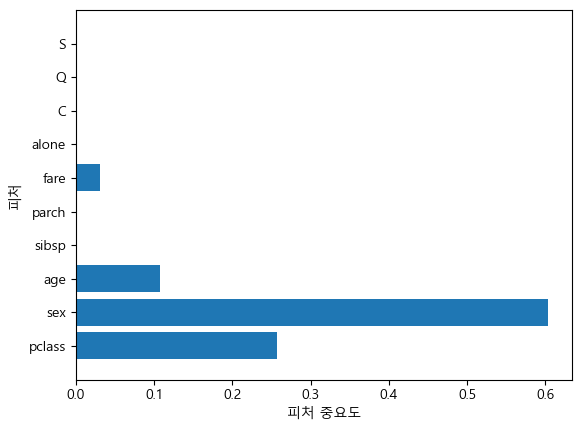

In [19]:
import numpy as np
import matplotlib.pyplot as plt

print('피처 중요도 :', model.feature_importances_)

plt.rcParams['font.family'] = 'Malgun Gothic'
n_features = X_train.shape[1]
plt.barh(np.arange(n_features), model.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel('피처 중요도')
plt.ylabel('피처')
plt.ylim(-1, n_features)

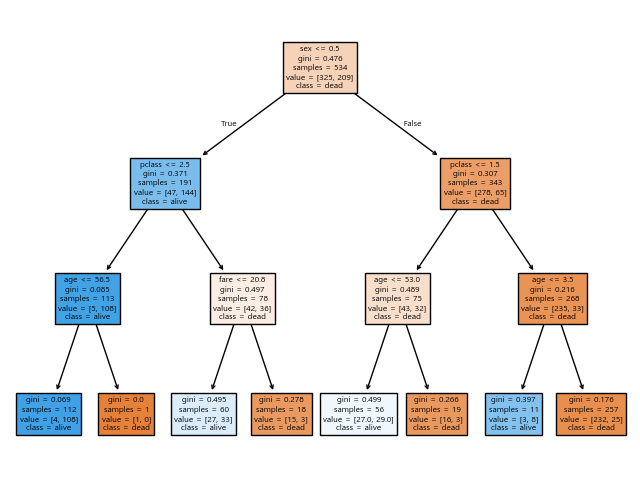

In [20]:
from sklearn.tree import plot_tree

label_val = {0:'dead', 1:'alive'}

plt.figure(figsize=(8,6))
plot_tree(model.fit(X_train, y_train), feature_names =X_train.columns, class_names = label_val, filled = True)
plt.show()

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Decision Tree 모델 생성
dt = DecisionTreeClassifier(random_state=42)

# 탐색할 파라미터 설정
param_grid = {
    "max_depth": [None, 3, 5, 7, 10],
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_leaf_nodes": [None, 5, 10, 20, 30]
}

# GridSearchCV 설정
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 학습
grid_search.fit(X_train, y_train)

# 최적 파라미터 출력
print("최적 파라미터:")
print(grid_search.best_params_)

# 최고 교차검증 점수 출력
print("최고 CV 정확도:", grid_search.best_score_)

# 최적 모델 저장
best_model = grid_search.best_estimator_

# 테스트 데이터 예측
y_pred = best_model.predict(X_test)

# 테스트 정확도 출력
print("테스트 정확도:", accuracy_score(y_test, y_pred))

최적 파라미터:
{'criterion': 'gini', 'max_depth': None, 'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
최고 CV 정확도: 0.8183389172985365
테스트 정확도: 0.7078651685393258


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 모델 생성
dt = DecisionTreeClassifier(random_state=42)

# 파라미터 범위 설정
param_grid = {
    "max_depth": [None] + list(range(1, 21)),
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "min_samples_split": list(range(2, 21)),
    "min_samples_leaf": list(range(1, 11)),
    "max_leaf_nodes": [None] + list(range(2, 31))
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 학습
grid_search.fit(X_train, y_train)

# 결과 출력
print("최적 파라미터:")
print(grid_search.best_params_)

print("최고 CV 정확도:", grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 테스트 데이터 평가
y_pred = best_model.predict(X_test)
print("테스트 정확도:", accuracy_score(y_test, y_pred))

최적 파라미터:
{'criterion': 'entropy', 'max_depth': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 20, 'splitter': 'random'}
최고 CV 정확도: 0.8240169282313525
테스트 정확도: 0.7640449438202247


In [36]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import warnings

warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv("boston_house.csv")
df.head(2)

,AGE,B,RM,CRIM,DIS,INDUS,LSTAT,NOX,PTRATIO,RAD,ZN,TAX,CHAS,Target
0,65.2,396.9,6.575,0.00632,4.0900,2.31,4.98,0.538,15.3,1,18.0,296,0,24.0
1,78.9,396.9,6.421,0.02731,4.9671,7.07,9.14,0.469,17.8,2,0.0,242,0,21.6


In [38]:
X = df.drop('Target', axis=1)
y = df['Target']

In [39]:
reg = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter='best',
    max_depth=3,
    min_samples_leaf=10,
    random_state=100).fit(X,y)

In [40]:
reg.predict(X)[:3]

array([22.6506383 , 22.6506383 , 35.24782609])

In [41]:
for i, col in enumerate(X.columns):
    print(f'{col} 중요도 : {reg.feature_importances_[i]}')

AGE 중요도 : 0.0
B 중요도 : 0.0
RM 중요도 : 0.6777780289645088
CRIM 중요도 : 0.03439671315633408
DIS 중요도 : 0.0
INDUS 중요도 : 0.0
LSTAT 중요도 : 0.27923067295220727
NOX 중요도 : 0.0
PTRATIO 중요도 : 0.008594584926949964
RAD 중요도 : 0.0
ZN 중요도 : 0.0
TAX 중요도 : 0.0
CHAS 중요도 : 0.0


In [42]:
print(reg.get_params())

{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 100, 'splitter': 'best'}


In [43]:
print("정확도 : ", reg.score(X,y))

정확도 :  0.7737076435842268


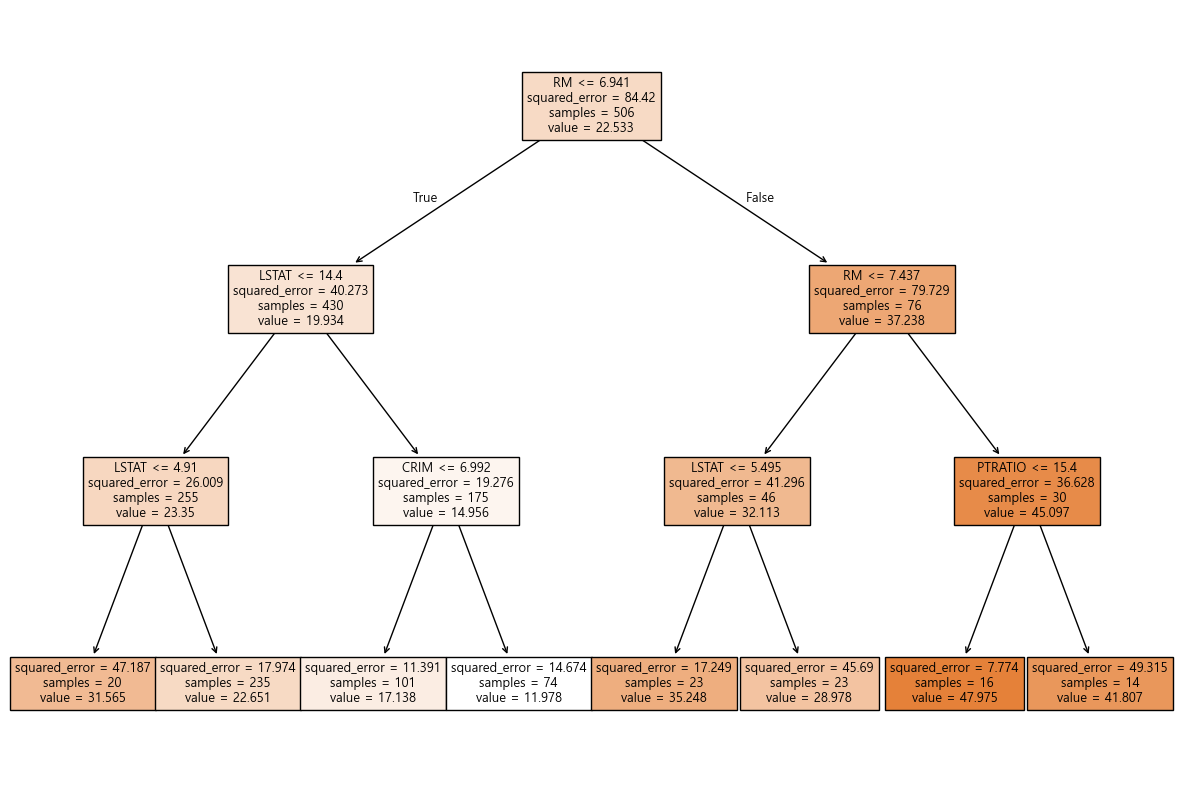

In [44]:
fig = plt.figure(figsize=(15, 10))
plot_tree(reg, feature_names=X.columns, filled=True)
plt.show()